# 🤖 Train Your First AI Model



![flowchart](./src/images/flowchart.png)

---

In this notebook you will **actually train a model yourself** — no prior coding experience needed.  
Along the way you'll discover what the words *data*, *input*, *output*, *training*, and *model* really mean.

👉 Run each cell with **Shift + Enter**. Read the text, then run the code.

---

## Step 0 — Install & import everything we need

Run this cell once to load the tools we'll use.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import os
# os.chdir('/content/drive/MyDrive/AIinRT_block2_tutorials')  # adjust path if needed

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
print("✅ Everything loaded. Let's go!")

✅ Everything loaded. Let's go!


---

## Step 1 — What is a model?

A **model** is a function that maps **inputs → outputs**.

![basic_model](./src/images/basic_model.png)

You may already know about models used in RT:

| Model | Input | Output |
|---|---|---|
| NTCP model | Dose features | Probability of toxicity (0–1) |
| Auto-segmentation | CT scan | Structure contours |
| Auto-planning | CT and contours | RT dose plan |


**What makes deep learning models special** is that the function is *learned directly from data*, rather than hand-coded by an expert.


---

## Step 2 — Meet your dataset

<img src="./src/images/data.png" alt="Drawing" style="width: 300px;"/>

We'll use a classic machine learning dataset: **handwritten digits dataset**.  
Each image is one handwritten number.

**Our task:** Given these images, can a model predict which digit (0-9) each image is?

Run the cell to load the data and take a look.

In [2]:
# Load the dataset
digits = load_digits()

X_all = digits.images
y_all = digits.target

X = X_all.reshape(X_all.shape[0], -1)  # inputs  (images)
y = y_all      # outputs (labels, i.e. which digit is in the image)

print(f"Number of images: {len(X)}")
print(f"Image size: {X_all.shape[1]} x {X_all.shape[2]} pixels")
print(f"Number of classes: {len(np.unique(y))}")

Number of images: 1797
Image size: 8 x 8 pixels
Number of classes: 10


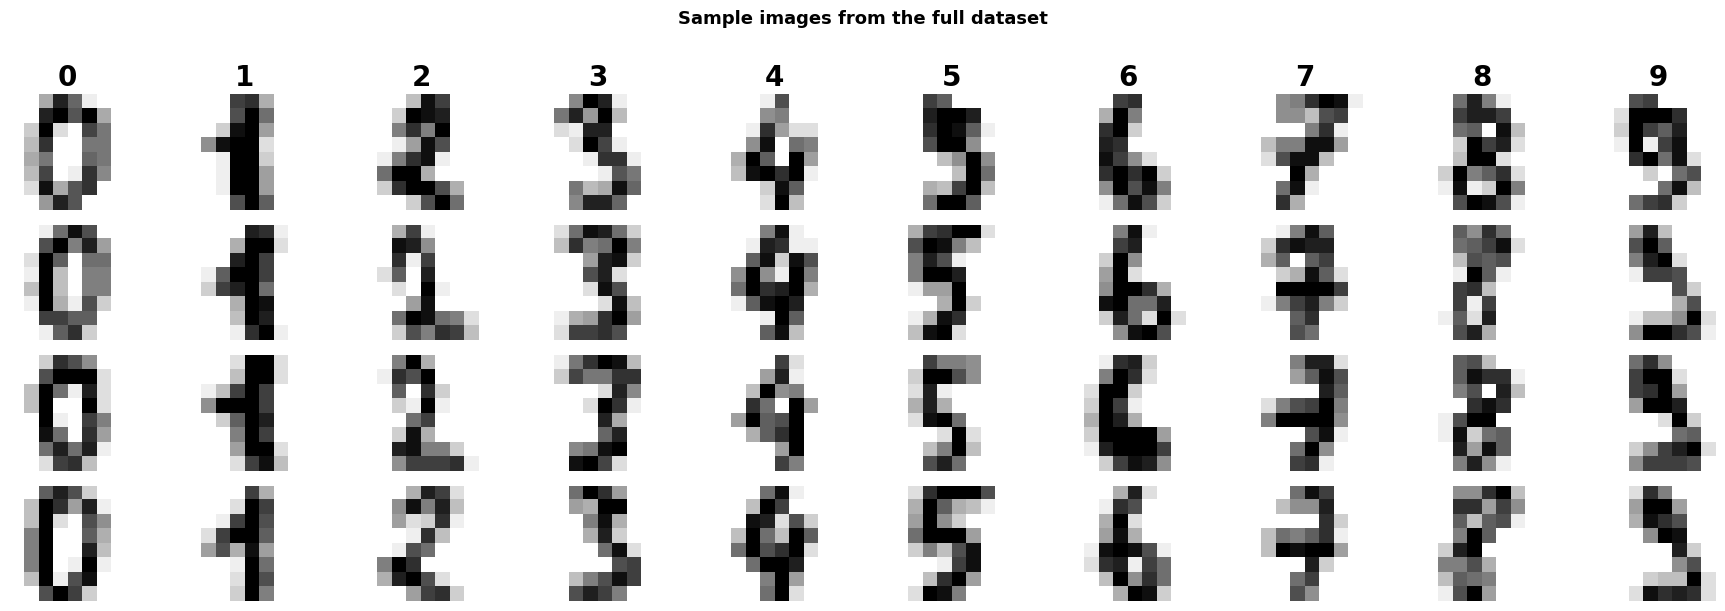

In [3]:
# Let's look at some examples of the data
from src.plot_examples import plot_example_data

plot_example_data(X_all, y_all, title="Sample images from the full dataset")

<div class="alert alert-block alert-info"> <b>💬 DISCUSS: </b> 

- What are the model inputs in this example?
- What are the labels?
- Which numbers might be most difficult to predict?

</div>

---

## Step 3 — Splitting data: training set vs test set

![data_split](./src/images/data_splitting.png)

A crucial concept: we **cannot evaluate a model on the same data we trained it on.**  
That would be like testing a student with the exact same exam questions they studied — it doesn't tell you if they truly understood.

So we split:

```
ALL DATA
   ├── TRAINING SET (80%)  ──►  model learns from this
   └── TEST SET    (20%)  ──►  we evaluate on this (model has never seen it)
```

Training set: 1437 images  ← model learns from these
Test set:     360 images   ← we use these to evaluate


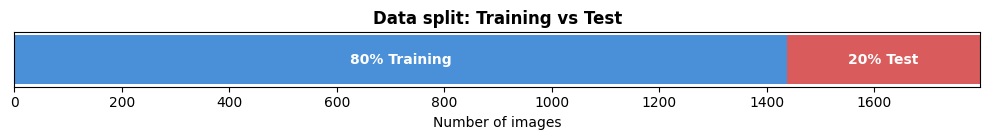

In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} images  ← model learns from these")
print(f"Test set:     {len(X_test)} images   ← we use these to evaluate")

# Visualise the split
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.barh(0, len(X_train), color='#4A90D9', height=0.5, label=f'Training ({len(X_train)})')
ax.barh(0, len(X_test), left=len(X_train), color='#D95B5B', height=0.5, label=f'Test ({len(X_test)})')
ax.set_xlim(0, len(X))
ax.set_yticks([])
ax.set_xlabel('Number of images')
ax.set_title('Data split: Training vs Test', fontweight='bold')
# ax.legend(loc='upper right')
ax.text(len(X_train)/2, 0, '80% Training', ha='center', va='center', color='white', fontweight='bold')
ax.text(len(X_train) + len(X_test)/2, 0, '20% Test', ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info"> <b>💬 DISCUSS: </b> 

- Why can't we just use all data for training?
- What would happen if we evaluated on training data?

</div>

---

## Step 4 — Train your first machine learning model! 🎉

We'll train a **logistic regression** model. It learns a weighted combination of the input features to produce a probability between 0 and 1.

**Training = the model finding the best weights from your training data.**

The whole training process happens in one line of code:

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1, random_state=42)
# 🎓 TRAIN THE MODEL — this is where learning happens
model.fit(X_train, y_train)  # ← this one line does all the learning

print("✅ Model trained!")

✅ Model trained!


---

## Step 5 — Make predictions on new patients

Now let's use the model on the **test set** — patients it has never seen before.

For each patient, the model outputs a **probability** (0 to 1), then classifies above 0.5 as benign.

In [6]:
# Get predictions on the test set
y_pred       = model.predict(X_test)           # 0 or 1

# Show the first 10 test images
print("First 10 test images:")
print(f"{'Sample':>8} | {'True label':>12} | {'Predicted':>12}  {'Correct?':>9}")
print("-" * 62)
for i in range(10):
    true     = y_test[i] 
    pred     = y_pred[i]
    correct  = '✅' if y_test[i] == y_pred[i] else '❌'
    print(f"{i+1:>8} | {true:>12} | {pred:>12} | {correct:>9}")


First 10 test images:
  Sample |   True label |    Predicted   Correct?
--------------------------------------------------------------
       1 |            6 |            6 |         ✅
       2 |            9 |            3 |         ❌
       3 |            3 |            3 |         ✅
       4 |            7 |            7 |         ✅
       5 |            2 |            2 |         ✅
       6 |            1 |            2 |         ❌
       7 |            5 |            5 |         ✅
       8 |            2 |            2 |         ✅
       9 |            5 |            5 |         ✅
      10 |            2 |            2 |         ✅


---

## Step 6 — How good is the model? Evaluating performance

Overall accuracy on test set: 68.6%
(i.e. the model got 247 out of 360 patients correct)



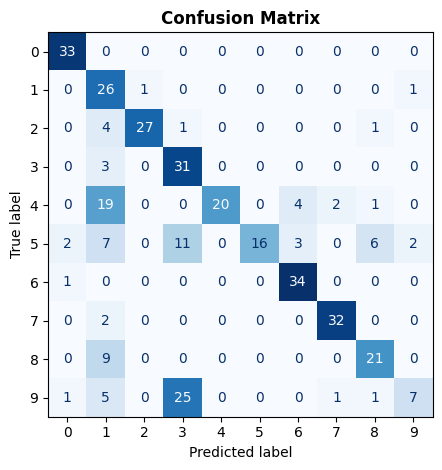

In [7]:
# Compute accuracy and show confusion matrix
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"Overall accuracy on test set: {acc*100:.1f}%")
print(f"(i.e. the model got {int(acc*len(y_test))} out of {len(y_test)} patients correct)\n")

# Single plot (no subfigures)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info"> <b>💬 DISCUSS: </b> 

- Which class (number) does the model predict correctly most often?
- Which class (number) is the most difficult for the model to predict? and why might this be?

</div>

---

## 🏁 Summary

In this notebook you:

1. ✅ Loaded a **dataset** with inputs (measurements) and outputs (labels)
2. ✅ Split it into a **training set** and a **test set**
3. ✅ **Trained a model** — the model learned a function from the training data
4. ✅ Used the model to **make predictions** on unseen patients
5. ✅ **Evaluated** the model and saw where it made mistakes

---

### ➡️ In Block 2 we'll go deeper:
*How is model quality reported in literature? When can you trust the numbers? And what happens when a deployed model starts to fail?*